<a href="https://colab.research.google.com/github/sakethyalamanchili/SimpleML-Projects/blob/main/food101_CNN-Practice_TF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks and Computer Vision with TensorFlow.

In [1]:
import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")

Notebook last run (end-to-end): 2025-08-22 18:12:04.729971


In [2]:
# !pip install gdown

In [3]:
import gdown
gdown.download(id="1FgkhkrpzFmQMK838ILGLpjBYBpWtZ_ON", output="data.zip", quiet=False)

!unzip data.zip

Downloading...
From (original): https://drive.google.com/uc?id=1FgkhkrpzFmQMK838ILGLpjBYBpWtZ_ON
From (redirected): https://drive.google.com/uc?id=1FgkhkrpzFmQMK838ILGLpjBYBpWtZ_ON&confirm=t&uuid=10e13bab-d477-4932-8b21-561c17dc7001
To: /content/data.zip
100%|██████████| 110M/110M [00:02<00:00, 54.5MB/s]


Archive:  data.zip
   creating: pizza_steak/
   creating: pizza_steak/test/
   creating: pizza_steak/train/
   creating: pizza_steak/test/steak/
   creating: pizza_steak/test/pizza/
   creating: pizza_steak/train/steak/
   creating: pizza_steak/train/pizza/
  inflating: pizza_steak/test/steak/413497.jpg  
  inflating: pizza_steak/test/steak/2246332.jpg  
  inflating: pizza_steak/test/steak/2649745.jpg  
  inflating: pizza_steak/test/steak/2382600.jpg  
  inflating: pizza_steak/test/steak/296375.jpg  
  inflating: pizza_steak/test/steak/2484823.jpg  
  inflating: pizza_steak/test/steak/400951.jpg  
  inflating: pizza_steak/test/steak/285269.jpg  
  inflating: pizza_steak/test/steak/2475366.jpg  
  inflating: pizza_steak/test/steak/1982192.jpg  
  inflating: pizza_steak/test/steak/2071320.jpg  
  inflating: pizza_steak/test/steak/2353677.jpg  
  inflating: pizza_steak/test/steak/2921355.jpg  
  inflating: pizza_steak/test/steak/3297938.jpg  
  inflating: pizza_steak/test/steak/1166047.jp

In [4]:
!ls pizza_steak

test  train


In [5]:
!ls pizza_steak/train/

pizza  steak


In [6]:
!ls pizza_steak/train/steak/

1000205.jpg  1647351.jpg  2238681.jpg  2824680.jpg  3375959.jpg  417368.jpg
100135.jpg   1650002.jpg  2238802.jpg  2825100.jpg  3381560.jpg  4176.jpg
101312.jpg   165639.jpg   2254705.jpg  2826987.jpg  3382936.jpg  42125.jpg
1021458.jpg  1658186.jpg  225990.jpg   2832499.jpg  3386119.jpg  421476.jpg
1032846.jpg  1658443.jpg  2260231.jpg  2832960.jpg  3388717.jpg  421561.jpg
10380.jpg    165964.jpg   2268692.jpg  285045.jpg   3389138.jpg  438871.jpg
1049459.jpg  167069.jpg   2271133.jpg  285147.jpg   3393547.jpg  43924.jpg
1053665.jpg  1675632.jpg  227576.jpg   2855315.jpg  3393688.jpg  440188.jpg
1068516.jpg  1678108.jpg  2283057.jpg  2856066.jpg  3396589.jpg  442757.jpg
1068975.jpg  168006.jpg   2286639.jpg  2859933.jpg  339891.jpg	 443210.jpg
1081258.jpg  1682496.jpg  2287136.jpg  286219.jpg   3417789.jpg  444064.jpg
1090122.jpg  1684438.jpg  2291292.jpg  2862562.jpg  3425047.jpg  444709.jpg
1093966.jpg  168775.jpg   229323.jpg   2865730.jpg  3434983.jpg  447557.jpg
1098844.jpg  1697

In [7]:
import os

# Walk through pizza_steak directory and list number of files
for dirpath, dirnames, filenames in os.walk("pizza_steak"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'pizza_steak'.
There are 2 directories and 0 images in 'pizza_steak/test'.
There are 0 directories and 250 images in 'pizza_steak/test/pizza'.
There are 0 directories and 250 images in 'pizza_steak/test/steak'.
There are 2 directories and 0 images in 'pizza_steak/train'.
There are 0 directories and 750 images in 'pizza_steak/train/pizza'.
There are 0 directories and 750 images in 'pizza_steak/train/steak'.


In [8]:
# Another way to find out how many images are in a file
num_steak_images_train = len(os.listdir("pizza_steak/train/steak"))
num_steak_images_train

750

In [9]:
# Get the class names
import pathlib
import numpy as np
data_dir = pathlib.Path("pizza_steak/train/")
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['pizza' 'steak']


In [10]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def view_random_images(target_dir, target_class, num_images=4):
    # Full path to the target folder
    target_folder = os.path.join(target_dir, target_class)

    # Get list of all image files in the target folder
    image_files = os.listdir(target_folder)

    if len(image_files) == 0:
        raise ValueError(f"No images found in {target_folder}")

    # Randomly select images (without replacement)
    selected_images = random.sample(image_files, min(num_images, len(image_files)))

    # Plot images
    plt.figure(figsize=(10, 8))
    for i, img_file in enumerate(selected_images):
        img_path = os.path.join(target_folder, img_file)
        img = mpimg.imread(img_path)

        plt.subplot(2, 2, i+1)
        plt.imshow(img)
        plt.title(f"{target_class} - {img_file}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Displayed {len(selected_images)} random images from '{target_class}'")
    print(f"Last image shape: {img.shape}")

    return selected_images

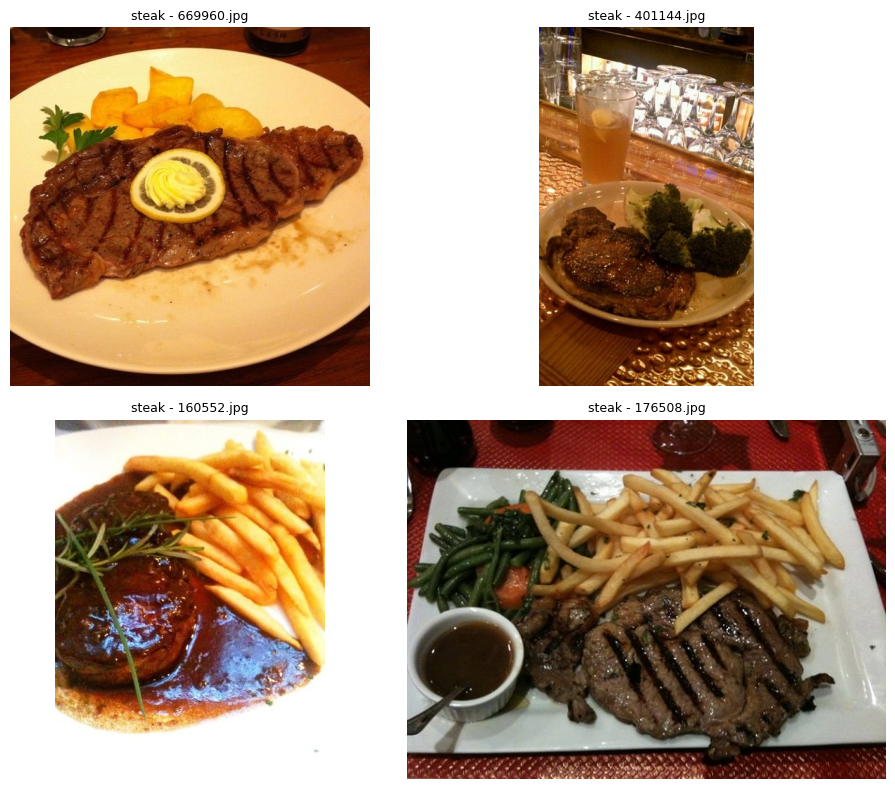

Displayed 4 random images from 'steak'
Last image shape: (384, 512, 3)


In [11]:
# View a random image from the training dataset
selected_images = view_random_images(target_dir="pizza_steak/train/",
                                     target_class="steak",
                                     num_images=4)

In [12]:
img_file = selected_images[0]
img_path = os.path.join("pizza_steak/train/", "steak", img_file)
img_array = mpimg.imread(img_path)
print(img_array)
print("Image Shape:", img_array.shape)
print("Pixel data type:", img_array.dtype)
print("Pixel values range:", img_array.min(), "to", img_array.max())

[[[222 178 107]
  [217 172 105]
  [218 172 113]
  ...
  [ 50  12   0]
  [ 48  10   0]
  [ 47   9   0]]

 [[219 174 107]
  [216 170 108]
  [211 164 110]
  ...
  [ 54  16   3]
  [ 53  15   2]
  [ 52  14   1]]

 [[218 173 114]
  [193 148  93]
  [162 116  67]
  ...
  [ 63  25  12]
  [ 59  21   8]
  [ 57  19   6]]

 ...

 [[ 79  17   4]
  [ 78  16   3]
  [ 76  14   1]
  ...
  [ 84  21   4]
  [ 89  23   7]
  [ 92  26  10]]

 [[ 78  18   7]
  [ 77  17   6]
  [ 77  17   6]
  ...
  [ 83  20   5]
  [ 83  20   5]
  [ 83  20   5]]

 [[ 77  17   6]
  [ 77  17   6]
  [ 77  17   6]
  ...
  [ 82  19   4]
  [ 78  15   0]
  [ 77  14   0]]]
Image Shape: (512, 512, 3)
Pixel data type: uint8
Pixel values range: 0 to 255


In [13]:
# Get all the pixel values between 0 & 1
img_array / 255.

array([[[0.87058824, 0.69803922, 0.41960784],
        [0.85098039, 0.6745098 , 0.41176471],
        [0.85490196, 0.6745098 , 0.44313725],
        ...,
        [0.19607843, 0.04705882, 0.        ],
        [0.18823529, 0.03921569, 0.        ],
        [0.18431373, 0.03529412, 0.        ]],

       [[0.85882353, 0.68235294, 0.41960784],
        [0.84705882, 0.66666667, 0.42352941],
        [0.82745098, 0.64313725, 0.43137255],
        ...,
        [0.21176471, 0.0627451 , 0.01176471],
        [0.20784314, 0.05882353, 0.00784314],
        [0.20392157, 0.05490196, 0.00392157]],

       [[0.85490196, 0.67843137, 0.44705882],
        [0.75686275, 0.58039216, 0.36470588],
        [0.63529412, 0.45490196, 0.2627451 ],
        ...,
        [0.24705882, 0.09803922, 0.04705882],
        [0.23137255, 0.08235294, 0.03137255],
        [0.22352941, 0.0745098 , 0.02352941]],

       ...,

       [[0.30980392, 0.06666667, 0.01568627],
        [0.30588235, 0.0627451 , 0.01176471],
        [0.29803922, 0

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)

# Preprocess data (get all of the pixel values between 1 and 0, also called scaling/normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup the train and test directories
train_dir = "pizza_steak/train/"
test_dir = "pizza_steak/test/"

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode="binary",
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(test_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode="binary",
                                               seed=42)

# Create a CNN model (same as Tiny VGG - https://poloclub.github.io/cnn-explainer/)
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size=3,
                           activation='relu',
                           input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(10, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2,
                              padding="valid"),
    tf.keras.layers.Conv2D(10, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_1.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

# Fit the model
history_1 = model_1.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 210ms/step - accuracy: 0.6397 - loss: 0.6364 - val_accuracy: 0.8460 - val_loss: 0.3838
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.8261 - loss: 0.3997 - val_accuracy: 0.8580 - val_loss: 0.3518
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - accuracy: 0.8514 - loss: 0.3644 - val_accuracy: 0.8560 - val_loss: 0.3418
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - accuracy: 0.8644 - loss: 0.3081 - val_accuracy: 0.8740 - val_loss: 0.3040
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.9143 - loss: 0.2464 - val_accuracy: 0.8640 - val_loss: 0.3134


In [15]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 29160)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        29,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,785 (366.35 KB)

 Trainable params: 31,261 (122.11 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,524 (244.24 KB)

In [16]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224, 3)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_2.compile(loss='binary_crossentropy',
                optimizer='Adam',
                metrics=['accuracy'])

history_2 = model_2.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - accuracy: 0.5463 - loss: 0.8263 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.5067 - loss: 0.6981 - val_accuracy: 0.5000 - val_loss: 0.6958
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.4719 - loss: 0.6946 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.4830 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.4811 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931


In [17]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │       602,116 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,806,425 (6.89 MB)

 Trainable params: 602,141 (2.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,204,284 (4.59 MB)

In [18]:
tf.random.set_seed(42)

model_3 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224, 3)),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_3.compile(loss='binary_crossentropy',
                optimizer='Adam',
                metrics=['accuracy'])

history_3 = model_3.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - accuracy: 0.5327 - loss: 6.1731 - val_accuracy: 0.7640 - val_loss: 0.7890
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.7456 - loss: 0.9222 - val_accuracy: 0.7100 - val_loss: 0.7269
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.7292 - loss: 0.6481 - val_accuracy: 0.6360 - val_loss: 0.9364
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.6994 - loss: 1.1024 - val_accuracy: 0.7880 - val_loss: 0.4621
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.7716 - loss: 0.5205 - val_accuracy: 0.7860 - val_loss: 0.4699


In [19]:
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │    15,052,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,219,605 (172.50 MB)

 Trainable params: 15,073,201 (57.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,146,404 (115.00 MB)

## Binary Classification: Let's break it down

We just went through a whirlwind of steps:
1. Become one with the data (Visualize, visualize, visualize ...)
2. Preprocess the data (prepare it for a model)
3. Create a model (start with a baseline)
4. Fit the model
5. Evaluate the model
6. Adjust different parameters and improve model (try to beat your baseline)
7. Repeat until satisfied

### 1. Import and become one with the data

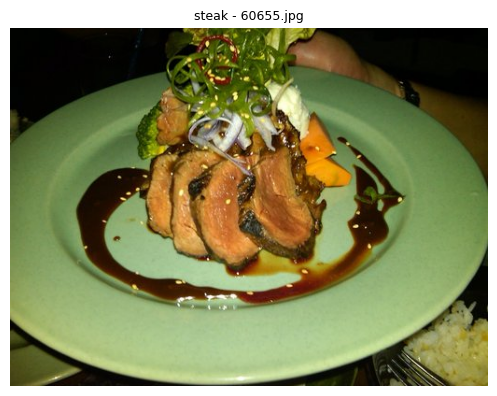

Displayed 1 random images from 'steak'
Last image shape: (384, 512, 3)


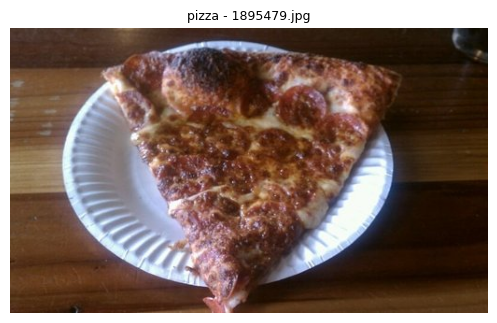

Displayed 1 random images from 'pizza'
Last image shape: (306, 512, 3)


['1895479.jpg']

In [20]:
view_random_images("pizza_steak/train/", "steak", 1)
view_random_images("pizza_steak/train/", "pizza", 1)

### 2. Preprocess the data (Prepare it for a model)

In [21]:
train_dir = "pizza_steak/train/"
test_dir = "pizza_steak/test/"

In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [23]:
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224,224),
                                               class_mode='binary',
                                               batch_size=32)

test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=(224,224),
                                             class_mode='binary',
                                             batch_size=32)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [24]:
# Get a sample of the training data batch
images, labels = next(train_data)
len(images), len(labels)

(32, 32)

In [25]:
# View the first batch of labels
labels

array([0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0., 0.,
       0., 0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1.],
      dtype=float32)

Due to the `class_mode` parameter being `binary` our labels are either `0` (pizza) or `1` (steak).

### 3. Create a model (start with a baseline)

In [26]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.models import Sequential

model_4 = Sequential([
    Conv2D(filters=10,
           kernel_size=3,
           strides=1,
           padding='valid',
           activation='relu',
           input_shape=(224, 224, 3)),
    Conv2D(10, 3, activation='relu'),
    Conv2D(10, 3, activation='relu'),
    Flatten(),
    Dense(1, activation='sigmoid')
])

In [27]:
# Compile the model
model_4.compile(loss='binary_crossentropy',
                optimizer='Adam',
                metrics=['accuracy'])

### 4. Fit a model

In [28]:
# Check lenghts of training and test data generators
len(train_data), len(test_data)

(47, 16)

In [29]:
# Fit the model
history_4 = model_4.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - accuracy: 0.5537 - loss: 1.0656 - val_accuracy: 0.7780 - val_loss: 0.5061
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 147ms/step - accuracy: 0.7749 - loss: 0.4843 - val_accuracy: 0.8060 - val_loss: 0.4098
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.8221 - loss: 0.4224 - val_accuracy: 0.8300 - val_loss: 0.3864
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.9106 - loss: 0.2644 - val_accuracy: 0.8240 - val_loss: 0.3922
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.9761 - loss: 0.1081 - val_accuracy: 0.8120 - val_loss: 0.4507


### 5. Evaluate the model

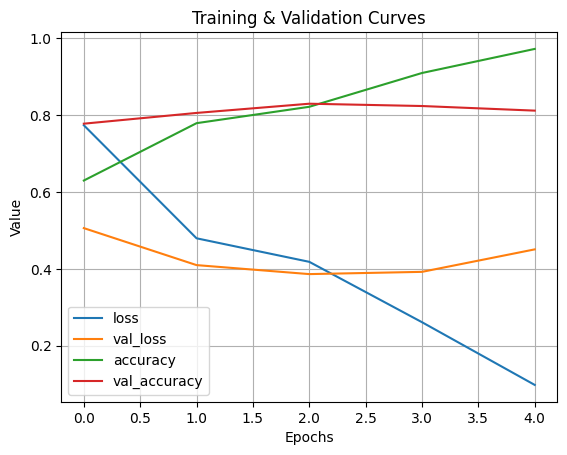

In [30]:
# Plot the training curves
import pandas as pd
pd.DataFrame(history_4.history)[["loss","val_loss","accuracy","val_accuracy"]].plot()
plt.title("Training & Validation Curves")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [31]:
# Plot the validation and training data separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.

  Args:
    history: TensorFlow model History object (see: https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/History)
  """
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

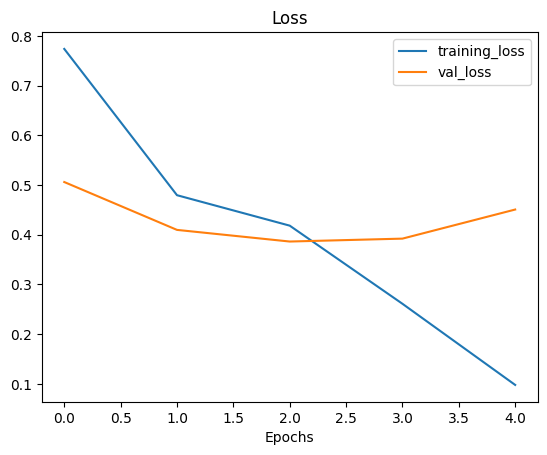

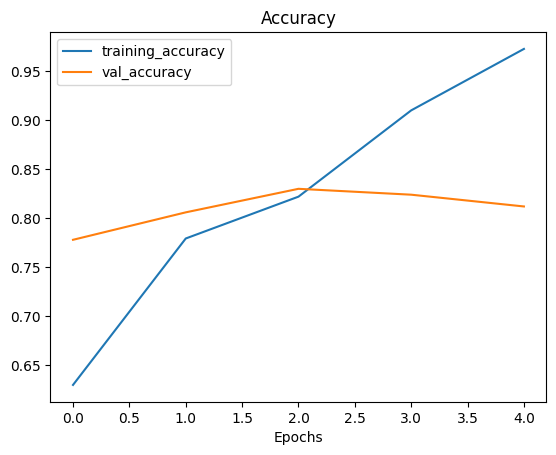

In [32]:
# Check out the loss curves of model_4
plot_loss_curves(history_4)

In [33]:
model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 218, 218, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 475240)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │       475,241 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,432,025 (5.46 MB)

 Trainable params: 477,341 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 954,684 (3.64 MB)

### 6. Adjust the model parameters

In [34]:
# Create the model (this can be our baseline, a 3 layer convolutional neural network)
model_5 = Sequential([
    Conv2D(10, 3, activation='relu', input_shape=(224,224,3)),
    MaxPool2D(pool_size=2),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
# Compile model (same as model_4)
model_5.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

In [36]:
# Fit the model
history_5 = model_5.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 156ms/step - accuracy: 0.6144 - loss: 0.6388 - val_accuracy: 0.8160 - val_loss: 0.3961
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.7758 - loss: 0.4654 - val_accuracy: 0.8360 - val_loss: 0.3964
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.8286 - loss: 0.4159 - val_accuracy: 0.8580 - val_loss: 0.3298
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.8109 - loss: 0.4247 - val_accuracy: 0.8540 - val_loss: 0.3242
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.8366 - loss: 0.3749 - val_accuracy: 0.8920 - val_loss: 0.3052


In [37]:
model_5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │         6,761 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,585 (103.85 KB)

 Trainable params: 8,861 (34.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,724 (69.24 KB)

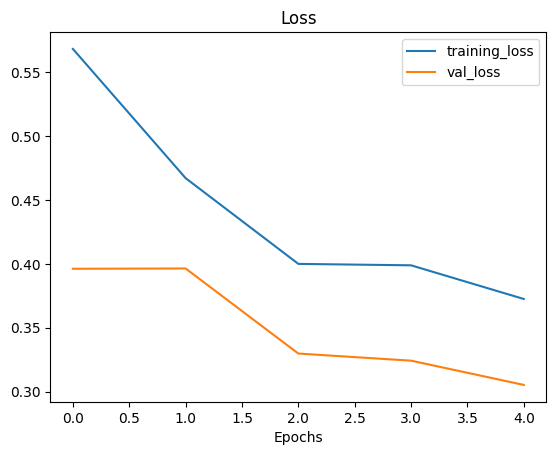

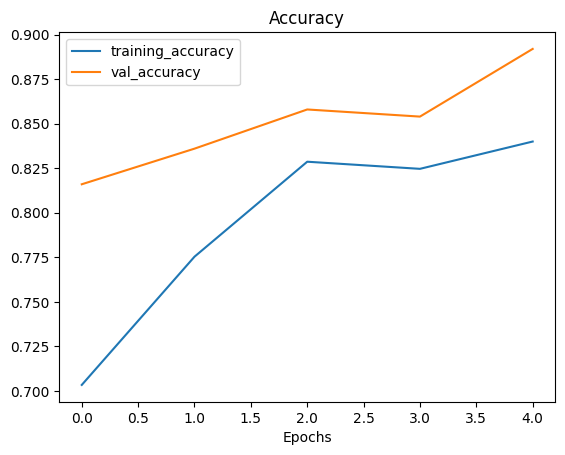

In [38]:
plot_loss_curves(history_5)

In [39]:
# Create ImageDataGenerator training instances with data augmentation
train_datagen_augmented = ImageDataGenerator(rescale=1./255,
                                             rotation_range=20,
                                             shear_range=0.2,
                                             zoom_range=0.2,
                                             width_shift_range=0.2,
                                             height_shift_range=0.2,
                                             horizontal_flip=True)

# Create ImageDataGenerator training instances without data augmentation
train_datagen = ImageDataGenerator(rescale=1./255)

# Create ImageDataGenerator test instances without data augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

In [40]:
# Import data and augment it from training directory
print("Augmented training images:")
train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   target_size=(224,224),
                                                                   batch_size=32,
                                                                   class_mode='binary',
                                                                   shuffle=False)

# Create non-augmented data batches
print("Non-augmented training images:")
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224,224),
                                               batch_size=32,
                                               class_mode='binary',
                                               shuffle=False)

print("Unchanged test images:")
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=(224,224),
                                             batch_size=32,
                                             class_mode='binary')

Augmented training images:
Found 1500 images belonging to 2 classes.
Non-augmented training images:
Found 1500 images belonging to 2 classes.
Unchanged test images:
Found 500 images belonging to 2 classes.


In [41]:
# Get data batch samples
images, labels = next(train_data)
augmented_images, augmented_labels = next(train_data_augmented)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

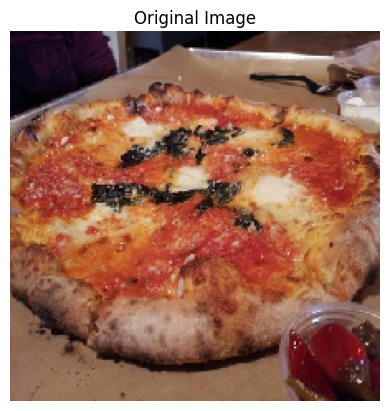

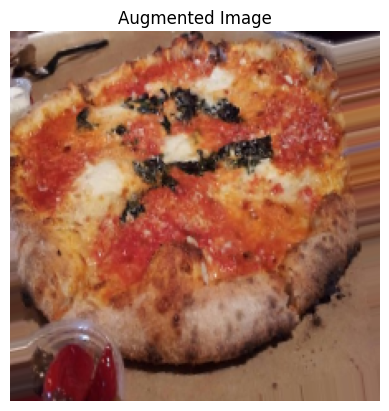

In [42]:
# Show original image and augmented image
random_number = random.randint(0, 31) # We're making batches of size 32, so we'll get a random instance
plt.imshow(images[random_number])
plt.title("Original Image")
plt.axis(False)
plt.figure()
plt.imshow(augmented_images[random_number])
plt.title("Augmented Image")
plt.axis(False)

In [43]:
# Create the model (same as model_5)
model_6 = Sequential([
    Conv2D(10, 3, activation='relu', input_shape=(224,224,3)),
    MaxPool2D(pool_size=2), # Reduces the number of features by half
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation='sigmoid')
])

# Compile the model
model_6.compile(loss='binary_crossentropy',
                optimizer='Adam',
                metrics=['accuracy'])

# Fit the model
history_6 = model_6.fit(train_data_augmented,
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented),
                        validation_data=test_data,
                        validation_steps=len(test_data))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 25s 470ms/step - accuracy: 0.7792 - loss: 1.2914 - val_accuracy: 0.5000 - val_loss: 0.9054
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 38s 435ms/step - accuracy: 0.3868 - loss: 0.7999 - val_accuracy: 0.5040 - val_loss: 0.6895
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 410ms/step - accuracy: 0.5454 - loss: 0.6880 - val_accuracy: 0.5020 - val_loss: 0.6854
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 436ms/step - accuracy: 0.4560 - loss: 0.6927 - val_accuracy: 0.5400 - val_loss: 0.6819
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 436ms/step - accuracy: 0.5673 - loss: 0.6803 - val_accuracy: 0.5420 - val_loss: 0.6781


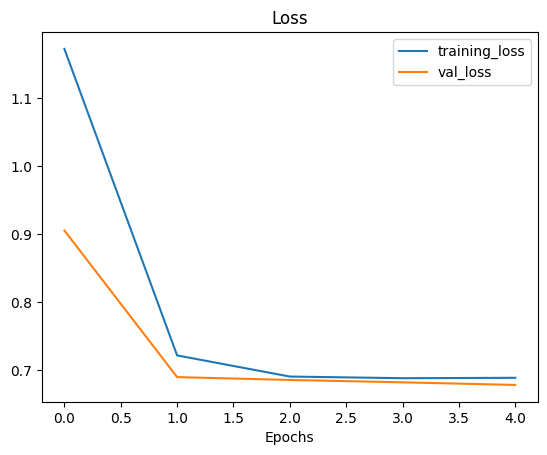

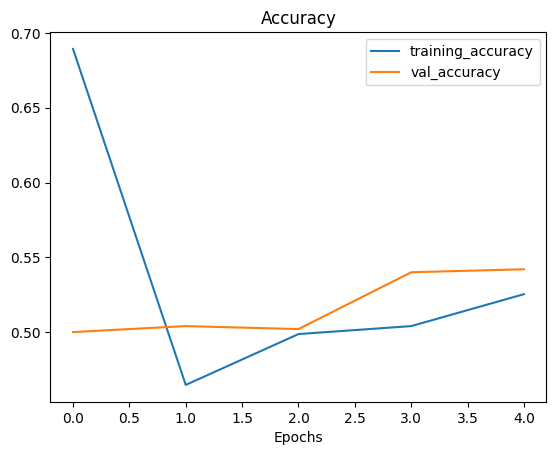

In [44]:
plot_loss_curves(history_6)

In [45]:
train_data_augmented_shuffled = train_datagen_augmented.flow_from_directory(train_dir,
                                                                            target_size=(224,224),
                                                                            batch_size=32,
                                                                            class_mode='binary',
                                                                            shuffle=True)

Found 1500 images belonging to 2 classes.


In [46]:
model_7 = Sequential([
    Conv2D(10, 3, activation='relu', input_shape=(224,224,3)),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model_7.compile(loss='binary_crossentropy',
                optimizer='Adam',
                metrics=['accuracy'])

history_7 = model_7.fit(train_data_augmented_shuffled,
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented_shuffled),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 30s 543ms/step - accuracy: 0.6077 - loss: 0.6589 - val_accuracy: 0.7480 - val_loss: 0.5152
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 557ms/step - accuracy: 0.7377 - loss: 0.5341 - val_accuracy: 0.8100 - val_loss: 0.4090
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 489ms/step - accuracy: 0.7647 - loss: 0.5147 - val_accuracy: 0.8440 - val_loss: 0.4018
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 458ms/step - accuracy: 0.7600 - loss: 0.5019 - val_accuracy: 0.8300 - val_loss: 0.3826
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 427ms/step - accuracy: 0.7539 - loss: 0.4985 - val_accuracy: 0.8240 - val_loss: 0.3873


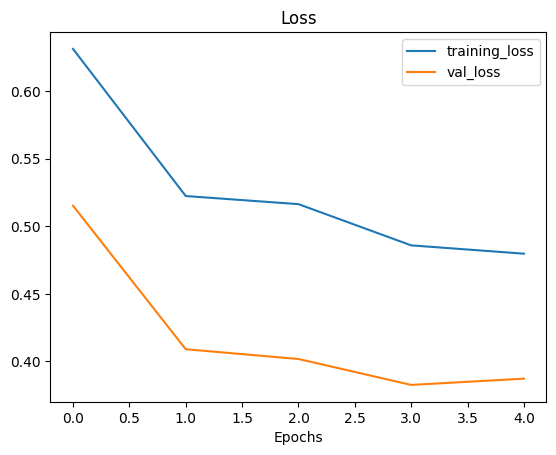

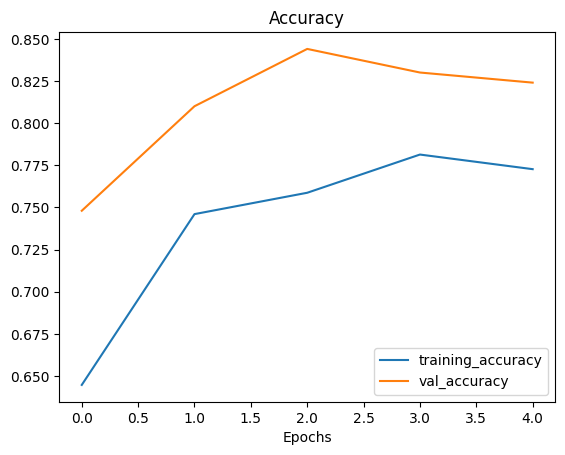

In [47]:
plot_loss_curves(history_7)

### 7. Repeat Steps Until Satisfied

In [48]:
model_8 = Sequential([
    Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu'),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model_8.compile(loss='binary_crossentropy',
                optimizer='Adam',
                metrics=['accuracy'])

history_8 = model_8.fit(train_data_augmented_shuffled,
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented_shuffled),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 30s 559ms/step - accuracy: 0.5583 - loss: 0.6685 - val_accuracy: 0.7680 - val_loss: 0.4842
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 34s 451ms/step - accuracy: 0.7274 - loss: 0.5391 - val_accuracy: 0.8220 - val_loss: 0.3896
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 453ms/step - accuracy: 0.7667 - loss: 0.5087 - val_accuracy: 0.8380 - val_loss: 0.4240
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 40s 439ms/step - accuracy: 0.7586 - loss: 0.4922 - val_accuracy: 0.8600 - val_loss: 0.3443
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 467ms/step - accuracy: 0.7665 - loss: 0.4787 - val_accuracy: 0.8540 - val_loss: 0.3468


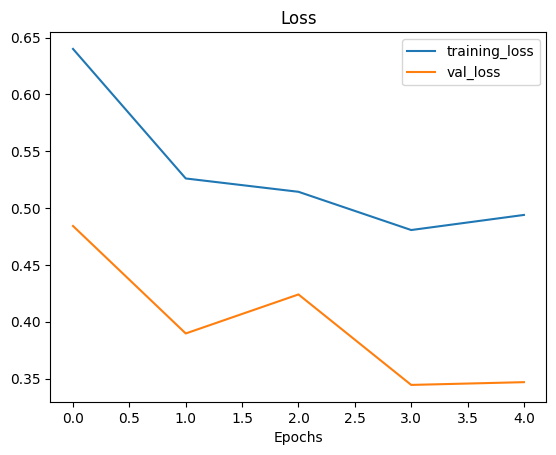

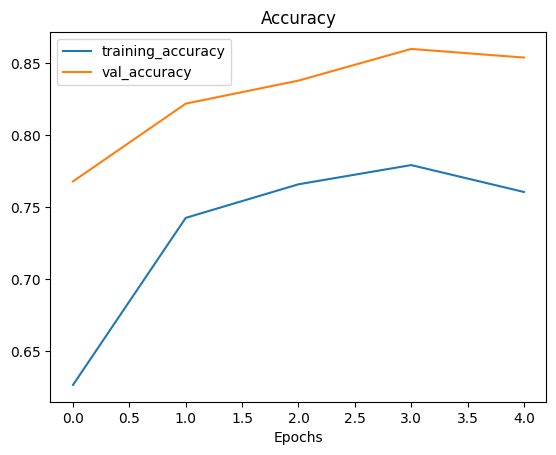

In [49]:
plot_loss_curves(history_8)

In [50]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 29160)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        29,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,785 (366.35 KB)

 Trainable params: 31,261 (122.11 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,524 (244.24 KB)

In [51]:
model_8.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

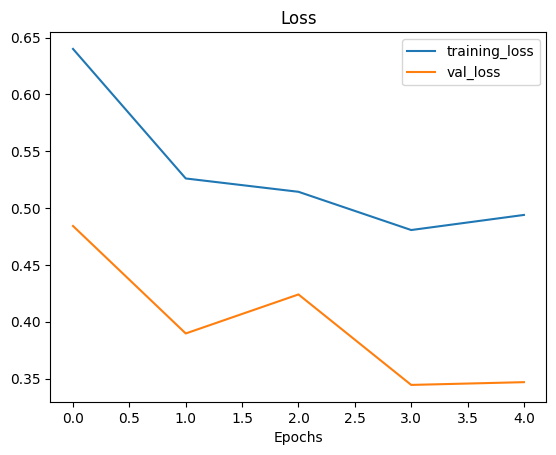

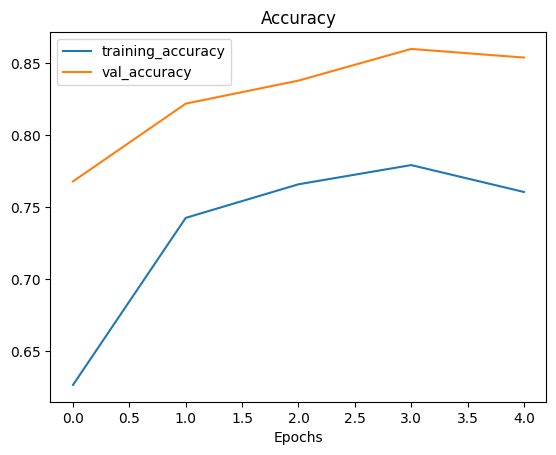

In [52]:
plot_loss_curves(history_8)

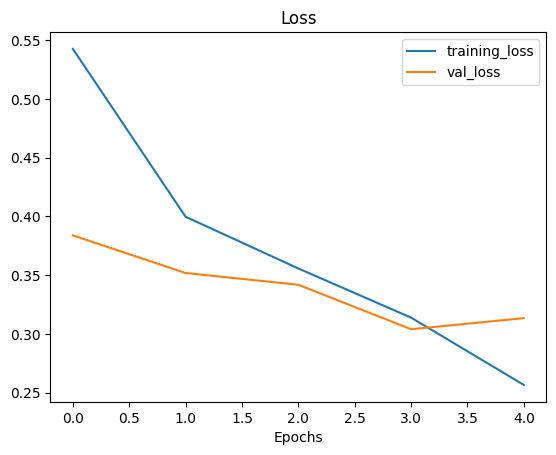

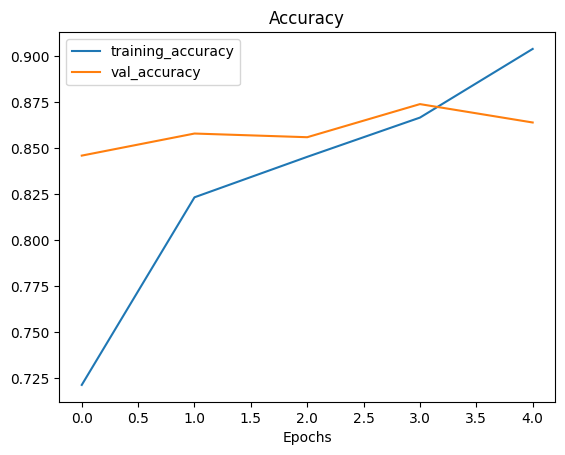

In [53]:
plot_loss_curves(history_1)

### Making a prediction with our trained model

In [54]:
print(class_names)

['pizza' 'steak']


--2025-08-22 18:22:27--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1978213 (1.9M) [image/jpeg]
Saving to: ‘03-steak.jpeg’

03-steak.jpeg       100%[===================>]   1.89M  --.-KB/s    in 0.04s   

2025-08-22 18:22:27 (51.0 MB/s) - ‘03-steak.jpeg’ saved [1978213/1978213]



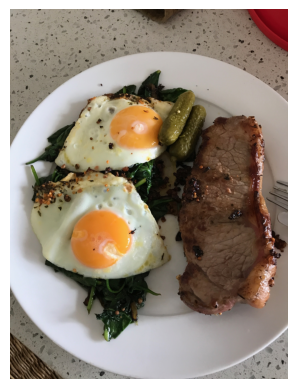

In [55]:
# View example image
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
steak = mpimg.imread("03-steak.jpeg")
plt.imshow(steak)
plt.axis(False);

In [56]:
steak.shape

(4032, 3024, 3)

In [57]:
# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(filename, img_shape=224):
  """
  Reads an image from filename, turns it into a tensor and reshape it to
  (img_shape, img_shape, color_channels).
  """
  # Reads target file (an image)
  img = tf.io.read_file(filename)

  # Decode the read file into a tensor & ensure 3 color channels
  img = tf.image.decode_image(img, channels=3)

  # Resize the image
  img = tf.image.resize(img, size=[img_shape, img_shape])

  # Rescale the image
  img = img/255.

  return img

In [58]:
# Load in and preprocess our custom image
steak = load_and_prep_image("03-steak.jpeg")
steak

<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[0.6377451 , 0.6220588 , 0.57892156],
        [0.6504902 , 0.63186276, 0.5897059 ],
        [0.63186276, 0.60833335, 0.5612745 ],
        ...,
        [0.52156866, 0.05098039, 0.09019608],
        [0.49509802, 0.04215686, 0.07058824],
        [0.52843136, 0.07745098, 0.10490196]],

       [[0.6617647 , 0.6460784 , 0.6107843 ],
        [0.6387255 , 0.6230392 , 0.57598037],
        [0.65588236, 0.63235295, 0.5852941 ],
        ...,
        [0.5352941 , 0.06862745, 0.09215686],
        [0.529902  , 0.05931373, 0.09460784],
        [0.5142157 , 0.05539216, 0.08676471]],

       [[0.6519608 , 0.6362745 , 0.5892157 ],
        [0.6392157 , 0.6137255 , 0.56764704],
        [0.65637255, 0.6269608 , 0.5828431 ],
        ...,
        [0.53137255, 0.06470589, 0.08039216],
        [0.527451  , 0.06862745, 0.1       ],
        [0.52254903, 0.05196078, 0.0872549 ]],

       ...,

       [[0.49313724, 0.42745098, 0.31029412],
        [0.05

In [59]:
# # Make a prediction on our custom image
# model_8.predict(steak)

In [60]:
# Add an extra axis
print(f"Shape before new dimension: {steak.shape}")
steak = tf.expand_dims(steak, axis=0)
print(f"Shape after new dimension: {steak.shape}")
steak

Shape before new dimension: (224, 224, 3)
Shape after new dimension: (1, 224, 224, 3)


<tf.Tensor: shape=(1, 224, 224, 3), dtype=float32, numpy=
array([[[[0.6377451 , 0.6220588 , 0.57892156],
         [0.6504902 , 0.63186276, 0.5897059 ],
         [0.63186276, 0.60833335, 0.5612745 ],
         ...,
         [0.52156866, 0.05098039, 0.09019608],
         [0.49509802, 0.04215686, 0.07058824],
         [0.52843136, 0.07745098, 0.10490196]],

        [[0.6617647 , 0.6460784 , 0.6107843 ],
         [0.6387255 , 0.6230392 , 0.57598037],
         [0.65588236, 0.63235295, 0.5852941 ],
         ...,
         [0.5352941 , 0.06862745, 0.09215686],
         [0.529902  , 0.05931373, 0.09460784],
         [0.5142157 , 0.05539216, 0.08676471]],

        [[0.6519608 , 0.6362745 , 0.5892157 ],
         [0.6392157 , 0.6137255 , 0.56764704],
         [0.65637255, 0.6269608 , 0.5828431 ],
         ...,
         [0.53137255, 0.06470589, 0.08039216],
         [0.527451  , 0.06862745, 0.1       ],
         [0.52254903, 0.05196078, 0.0872549 ]],

        ...,

        [[0.49313724, 0.42745098, 

Our Customer Image has a batch size of 1! Let's make a prediction on it.

In [61]:
# Make a prediction on customer image tensor
pred = model_8.predict(steak)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step


array([[0.8611207]], dtype=float32)

In [62]:
class_names

array(['pizza', 'steak'], dtype='<U5')

In [63]:
# We can index the predicted class by rounding the prediction probability
pred_class = class_names[int(tf.round(pred))]
print(pred_class)

steak


In [64]:
def pred_and_plot(model, filename, class_names):
  """
  Imports an image located at filename, makes a prediction on it with
  a trained model and plots the image with the predicted class as the title.
  """
  # Import the target image and preprocess it
  img = load_and_prep_image(filename)

  # Make a prediction
  pred = model.predict(tf.expand_dims(img, axis=0)) # This makes the shape (1, 224, 224, 3)

  # Get the prediction class
  pred_class = class_names[int(tf.round(pred))]

  # Plot the image and predicted class
  plt.imshow(img)
  plt.title(f"Prediction: {pred_class}")
  plt.axis(False);

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


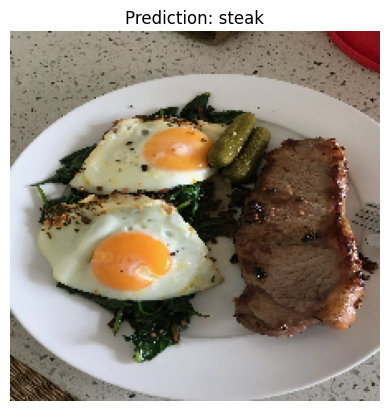

In [65]:
pred_and_plot(model_8, "03-steak.jpeg", class_names)

--2025-08-22 18:22:30--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-pizza-dad.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2874848 (2.7M) [image/jpeg]
Saving to: ‘03-pizza-dad.jpeg’

03-pizza-dad.jpeg   100%[===================>]   2.74M  --.-KB/s    in 0.04s   

2025-08-22 18:22:31 (64.4 MB/s) - ‘03-pizza-dad.jpeg’ saved [2874848/2874848]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


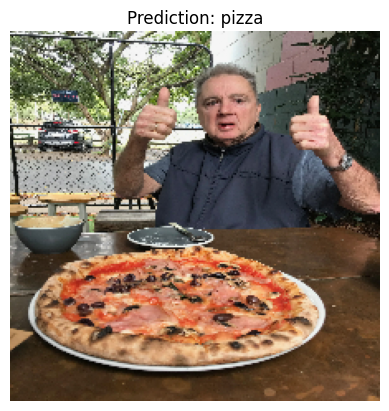

In [66]:
# Download another test image and make a prediction on it
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-pizza-dad.jpeg
pred_and_plot(model_8, "03-pizza-dad.jpeg", class_names)

## Multi-Class Classification

We will follow almost the same steps as we did for Binary Classification, except this time, we'll work with 10 different types of food.
1. Become one with the data (visualize, visualize, visualize ... )
2. Preprocess the data (Prepare it for a model)
3. Create a model (start with a baseline)
4. Fit the model
5. Evaluate the model
6. Adjust different parameters and improve model (try to beat your baseline)
7. Repeat until satisfied

<img src="https://camo.githubusercontent.com/88c909c31380460b8948ac6c8b9a1e86211008c1cdb590049bf2a6fe1a6ab030/68747470733a2f2f7261772e67697468756275736572636f6e74656e742e636f6d2f6d7264626f75726b652f74656e736f72666c6f772d646565702d6c6561726e696e672f6d61696e2f696d616765732f6d6973632d74656e736f72666c6f772d776f726b666c6f772d6f75746c696e652e706e67" alt="Image of Steps we follow">

### 1. Import and become one with the data

In [67]:
import zipfile

# Download zip file of 10_food_classes images
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

# Unzip the downloaded file
zip_ref = zipfile.ZipFile("10_food_classes_all_data.zip",'r')
zip_ref.extractall()
zip_ref.close()

--2025-08-22 18:22:31--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 192.178.163.207, 173.194.202.207, 173.194.203.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|192.178.163.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M   272MB/s    in 1.8s    

2025-08-22 18:22:33 (272 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [68]:
import os

# Walk through 10_food_classes directory and list number of files
for dirpath, dirnames, filename in os.walk("10_food_classes_all_data"):
  print(f"There are {len(dirnames)} directories and {len(filename)} images in '{dirpath}'.")

There are 2 directories and 0 images in '10_food_classes_all_data'.
There are 10 directories and 0 images in '10_food_classes_all_data/test'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/fried_rice'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/sushi'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/chicken_wings'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/hamburger'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/grilled_salmon'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/ramen'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/pizza'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/ice_cream'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/steak'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/chicken_curry'.
There are 

In [69]:
train_dir = "10_food_classes_all_data/train/"
test_dir = "10_food_classes_all_data/test/"

In [70]:
# Get the class names for our multi-class dataset
import pathlib
import numpy as np
data_dir = pathlib.Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


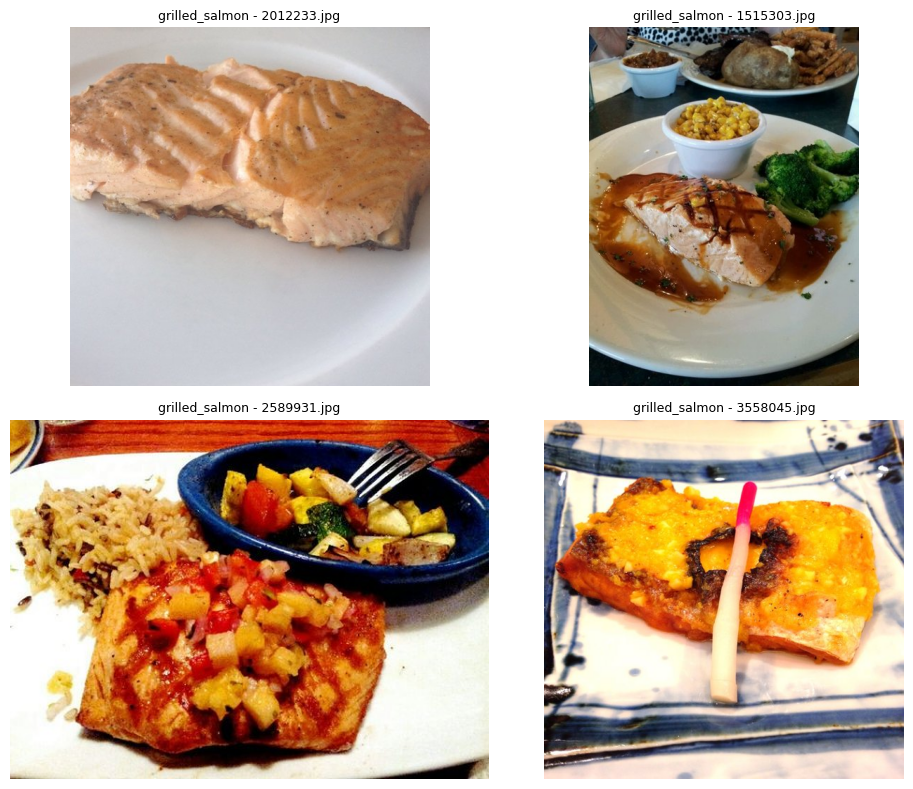

Displayed 4 random images from 'grilled_salmon'
Last image shape: (512, 512, 3)


In [71]:
# View a random image from the training dataset

import random
img = view_random_images(target_dir = train_dir,
                         target_class = random.choice(class_names))

### 2. Preprocess the data (prepare it for a model)

In [72]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224,224),
                                               batch_size=32,
                                               class_mode='categorical')

test_data = test_datagen.flow_from_directory(test_dir,
                                            target_size=(224,224),
                                            batch_size=32,
                                            class_mode='categorical')

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


### 3. Create a model (start with a baseline)

In [73]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

model_9 = Sequential([
    Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu'),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(10, activation='softmax')
])

model_9.compile(loss="categorical_crossentropy",
                optimizer='Adam',
                metrics=["accuracy"])

### 4. Fit a model

In [74]:
history_9 = model_9.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 45s 179ms/step - accuracy: 0.1620 - loss: 2.2374 - val_accuracy: 0.2896 - val_loss: 2.0101
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 74s 151ms/step - accuracy: 0.3427 - loss: 1.8950 - val_accuracy: 0.3248 - val_loss: 1.9314
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 105ms/step - accuracy: 0.4663 - loss: 1.6012 - val_accuracy: 0.3620 - val_loss: 1.8435
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 46s 125ms/step - accuracy: 0.6621 - loss: 1.0545 - val_accuracy: 0.3124 - val_loss: 2.1957
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step - accuracy: 0.8598 - loss: 0.4659 - val_accuracy: 0.2900 - val_loss: 3.1679


### 5. Evaluate the model

In [75]:
model_9.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.2900 - loss: 3.1569


[3.1678855419158936, 0.28999999165534973]

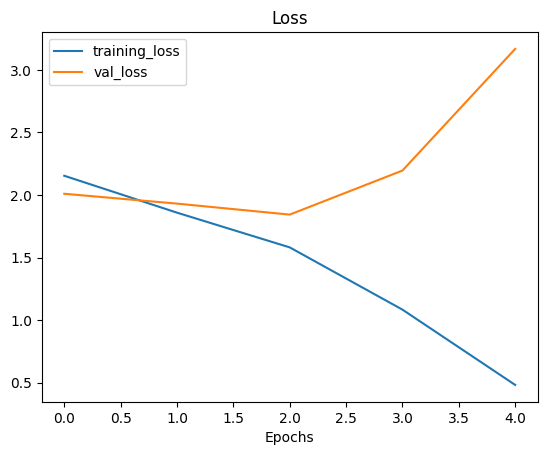

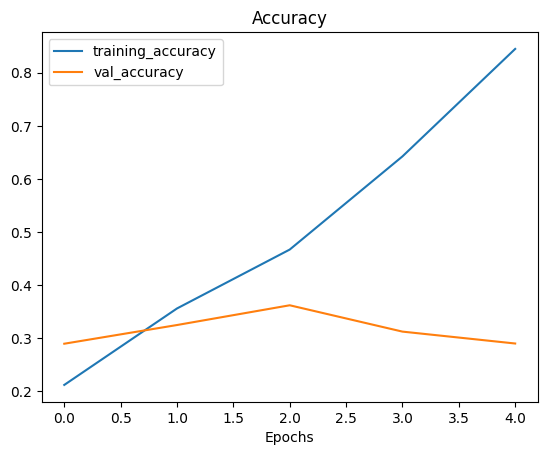

In [76]:
plot_loss_curves(history_9)

We can clearly see lot of gap between the training and validation loss curves. It seems our model is overfitting the training set quite badly. In other words, it's getting great results on the training data but fails to generalize well to unseen data and performs poorly on the test data.

### 6. Adjust the model parameters

Our next steps will be to try and prevent our model overfitting. A couple of ways to prevent overfitting include:
- Get more data
- Simplify model
- Use data augmentation
- Use transfer learning

> **Note:** Preventing overfitting is also referred to as regularization.

In [77]:
# Try a simplified model
model_10 = Sequential([
    Conv2D(10, 3, activation='relu', input_shape=(224,224,3)),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(10, activation='softmax')
])

model_10.compile(loss='categorical_crossentropy',
                 optimizer="Adam",
                 metrics=['accuracy'])

In [78]:
history_10 = model_10.fit(train_data,
                          epochs=5,
                          steps_per_epoch=len(train_data),
                          validation_data=test_data,
                          validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 31s 121ms/step - accuracy: 0.1594 - loss: 2.3053 - val_accuracy: 0.2536 - val_loss: 2.0796
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - accuracy: 0.3382 - loss: 1.9102 - val_accuracy: 0.3092 - val_loss: 1.9648
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0.4861 - loss: 1.5400 - val_accuracy: 0.3184 - val_loss: 1.9219
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 24s 103ms/step - accuracy: 0.6665 - loss: 1.0692 - val_accuracy: 0.3372 - val_loss: 2.0316
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 103ms/step - accuracy: 0.8230 - loss: 0.6233 - val_accuracy: 0.3004 - val_loss: 2.4046


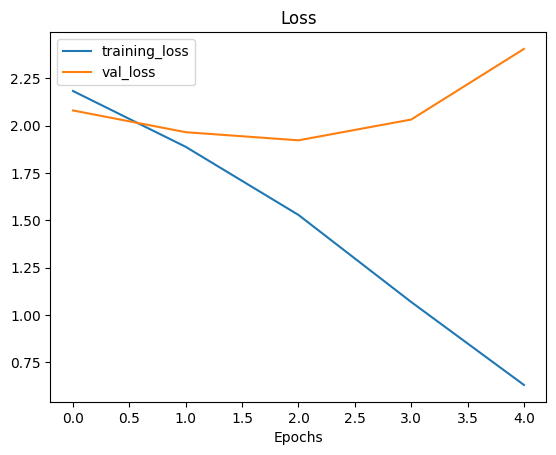

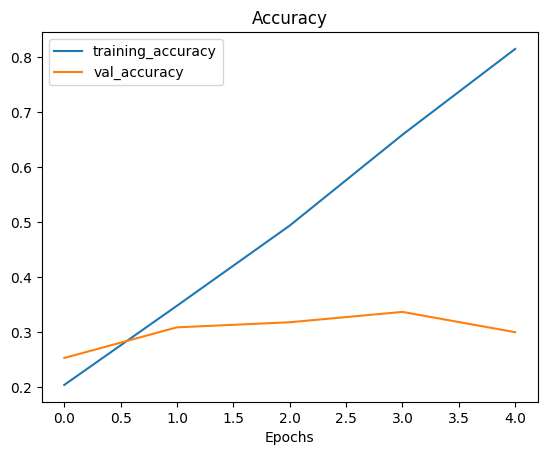

In [79]:
plot_loss_curves(history_10)

Still not Satified!!! We shall try using Data Augmentation

In [80]:
train_datagen_augmented = ImageDataGenerator(rescale=1./255,
                                             rotation_range=20,
                                             width_shift_range=0.2,
                                             height_shift_range=0.2,
                                             zoom_range=0.2,
                                             horizontal_flip=True)

train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   target_size=(224,224),
                                                                   batch_size=32,
                                                                   class_mode='categorical')

Found 7500 images belonging to 10 classes.


> **Note:** One of the key practices in deep learning and machine learning in general is to be a serial experimenter. That's what we're doing here. Trying something, seeing if it works, then trying something else. A good experiment setup also keeps track of the things you change, for example, that's why we're using the same model as before but with different data. The model stays the same but the data changes, this will let us know if augmented training data has any influence over performance.

In [81]:
model_11 = tf.keras.models.clone_model(model_10)

model_11.compile(loss='categorical_crossentropy',
                 optimizer='Adam',
                 metrics=['accuracy'])

history_11 = model_11.fit(train_data_augmented,
                          epochs=5,
                          steps_per_epoch=len(train_data_augmented),
                          validation_data=test_data,
                          validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 107s 445ms/step - accuracy: 0.1576 - loss: 2.2634 - val_accuracy: 0.2700 - val_loss: 2.0054
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 105s 446ms/step - accuracy: 0.2609 - loss: 2.0766 - val_accuracy: 0.2972 - val_loss: 1.9669
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 161s 527ms/step - accuracy: 0.2900 - loss: 2.0218 - val_accuracy: 0.3576 - val_loss: 1.8793
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 113s 479ms/step - accuracy: 0.3028 - loss: 1.9849 - val_accuracy: 0.3492 - val_loss: 1.9048
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 119s 505ms/step - accuracy: 0.3195 - loss: 1.9671 - val_accuracy: 0.3552 - val_loss: 1.8643


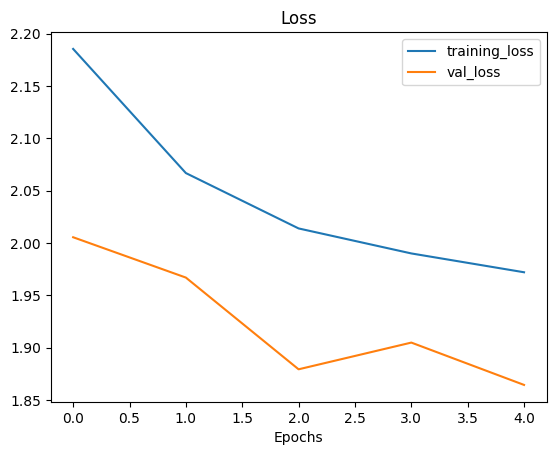

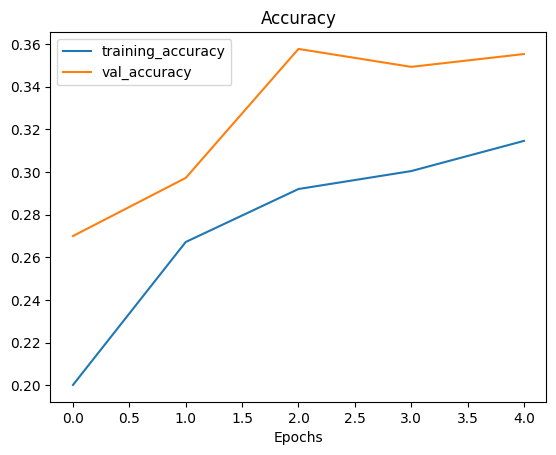

In [82]:
plot_loss_curves(history_11)

### 7. Repeat until satisfied

We could keep going here. Restructuring our model's architecture, adding more layers, trying it out, adjusting the learning rate, trying different methods of data augmentation, training for longer. But as you could image, this could take a fairly long time.

Good thing there's still one trick we haven't tried yet and that's tranfer learning, which we shall do it in the future!

### Making a prediction with our trained model

In [83]:
class_names

array(['chicken_curry', 'chicken_wings', 'fried_rice', 'grilled_salmon',
       'hamburger', 'ice_cream', 'pizza', 'ramen', 'steak', 'sushi'],
      dtype='<U14')

In [84]:
# -q is for "quiet"
!wget -q https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-pizza-dad.jpeg
!wget -q https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
!wget -q https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-hamburger.jpeg
!wget -q https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-sushi.jpeg

In [88]:
def pred_and_plot(model, filename, class_names):
  """
  Imports an Image from filename, makes a prediction with model and
  plots the image with the predicted class as the title.
  """
  # Import the target image and preproces it: Reads -> Decodes -> Resize
  img = load_and_prep_image(filename)

  # Make a prediction
  pred = model.predict(tf.expand_dims(img, axis=0))

  # Get the predicted class
  if len(pred[0]) > 1: # Check for multiclass because if it is binary it stays between 0 and 1
    pred_class = class_names[pred.argmax()] # If more than one output, take the max index
  else:
    pred_class = class_names[int(tf.round(pred))]

  plt.imshow(img)
  plt.title(f"Prediction: {pred_class}")
  plt.axis(False);

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


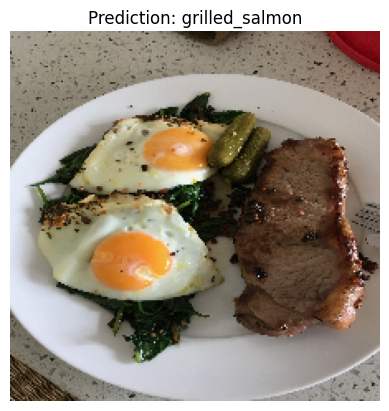

In [89]:
pred_and_plot(model_11, "03-steak.jpeg", class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


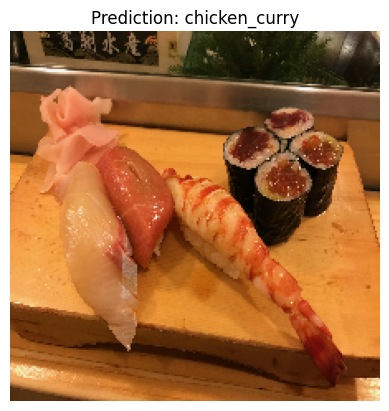

In [90]:
pred_and_plot(model_11, "03-sushi.jpeg", class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


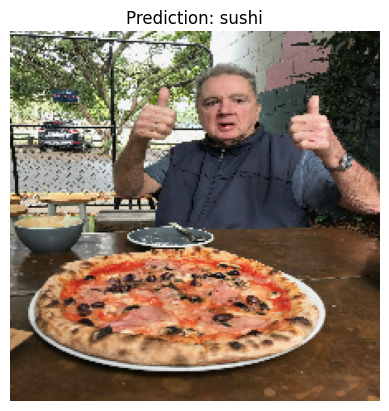

In [91]:
pred_and_plot(model_11, "03-pizza-dad.jpeg", class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


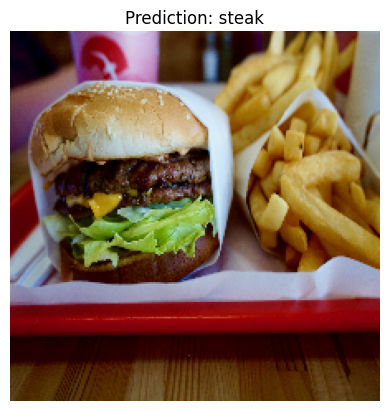

In [92]:
pred_and_plot(model_11, "03-hamburger.jpeg", class_names)

### Saving and loading our model

In [94]:
# Save a model
model_11.save("saved_trained_model.h5")

In [95]:
# Load in a model and evaluate it
loaded_model_11 = tf.keras.models.load_model("saved_trained_model.h5")
loaded_model_11.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.3555 - loss: 1.8495


[1.8643450736999512, 0.35519999265670776]

In [96]:
model_11.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.3595 - loss: 1.8644


[1.8643450736999512, 0.35519999265670776]